<a href="https://colab.research.google.com/github/NupoorRaut/Deep-Learning/blob/main/01_DNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


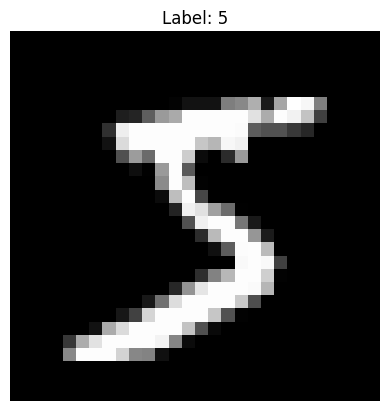

In [ ]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()


In [ ]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("One-hot label example:", y_train_cat[0])


One-hot label example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
def create_model(optimizer):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "Adam": Adam(),
    "RMSprop": RMSprop()
}


In [ ]:
histories = {}
predictions = {}

for name, opt in optimizers.items():
    print(f"\nTraining using {name} optimizer")

    model = create_model(opt)

    history = model.fit(
        x_train, y_train_cat,
        epochs=10,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    histories[name] = history
    predictions[name] = model.predict(x_test)



Training using SGD optimizer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4824 - loss: 1.7688 - val_accuracy: 0.8748 - val_loss: 0.6075
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8547 - loss: 0.5939 - val_accuracy: 0.9067 - val_loss: 0.3784
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8835 - loss: 0.4256 - val_accuracy: 0.9153 - val_loss: 0.3149
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8965 - loss: 0.3674 - val_accuracy: 0.9185 - val_loss: 0.2859
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9043 - loss: 0.3364 - val_accuracy: 0.9252 - val_loss: 0.2650
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9095 - loss: 0.3146 - val_accuracy: 0.9270 - val_loss: 0.2507
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9120 - loss: 0.3054 - val_accuracy: 0.9300 - val_loss: 0.2409
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9179 - loss: 0.2859 - val_accuracy: 0.

In [ ]:
for name, history in histories.items():
    print(f"\n{name} Optimizer Results:")
    print("Final Training Accuracy:", history.history['accuracy'][-1])
    print("Final Validation Accuracy:", history.history['val_accuracy'][-1])



SGD Optimizer Results:
Final Training Accuracy: 0.9257962703704834
Final Validation Accuracy: 0.9383333325386047

Adam Optimizer Results:
Final Training Accuracy: 0.9927407503128052
Final Validation Accuracy: 0.9798333048820496

RMSprop Optimizer Results:
Final Training Accuracy: 0.99272221326828
Final Validation Accuracy: 0.9815000295639038


In [ ]:
y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2,3,4,5,6,7,8,9]
)


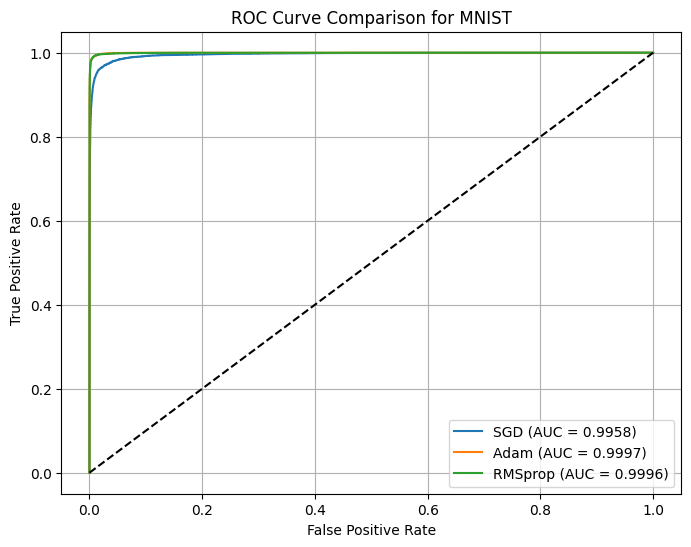

In [ ]:
plt.figure(figsize=(8,6))

for name, y_pred in predictions.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for MNIST")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [ ]:
# Choose best optimizer
best_optimizer = "Adam"

# Get predicted class labels
y_pred_classes = np.argmax(predictions[best_optimizer], axis=1)


In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)


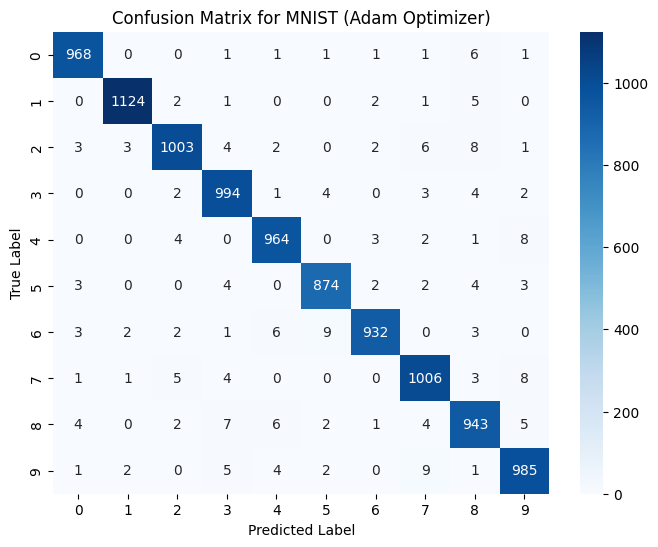

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for MNIST (Adam Optimizer)")
plt.show()


In [ ]:
from sklearn.metrics import classification_report
report = classification_report(
    y_test,
    y_pred_classes,
    target_names=[str(i) for i in range(10)]
)

print(report)


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.97      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.96      0.97      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



============================================================
CONCLUSION: MNIST NEURAL NETWORK OPTIMIZER COMPARISON
============================================================

Dataset:
- MNIST handwritten digit dataset with 60,000 training and 10,000 test images.
- Each image is 28x28 grayscale representing digits from 0 to 9.

Model:
- A fully connected neural network with two hidden layers was used.
- Same architecture was maintained for all optimizers to ensure fair comparison.

Optimizers Compared:
- Stochastic Gradient Descent (SGD)
- Adam Optimizer
- RMSprop Optimizer

Performance Evaluation Metrics:
- Accuracy and Loss
- ROC Curve and AUC Score (One-vs-Rest approach)
- Confusion Matrix
- Precision, Recall, and F1-score

Observations:
- Adam optimizer achieved the highest AUC and overall accuracy.
- RMSprop showed performance close to Adam with stable convergence.
- SGD converged slower and showed slightly lower performance.
- ROC curves for all optimizers were close to the top-left corner,
  indicating strong class separability.
- Confusion matrix showed strong diagonal dominance,
  confirming correct classification for most digits.
- Minor misclassifications occurred between visually similar digits.

Conclusion:
- Adam optimizer is best suited for MNIST digit classification
  due to adaptive learning rates and better noise handling.
- The neural network demonstrates robust and consistent performance
  across all digit classes.

Overall, the experimental results validate that optimizer choice
significantly affects convergence speed and classification performance.



In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

print("="*65)
print("RESULTS: OPTIMIZER-WISE PERFORMANCE ON MNIST")
print("="*65)

for name in predictions.keys():

    # Get predicted probabilities and classes
    y_pred_prob = predictions[name]
    y_pred_class = np.argmax(y_pred_prob, axis=1)

    # Accuracy
    acc = accuracy_score(y_test, y_pred_class)

    # AUC (micro-average, One-vs-Rest)
    auc_score = roc_auc_score(
        y_test_bin,
        y_pred_prob,
        average="micro",
        multi_class="ovr"
    )

    # Final training & validation accuracy
    train_acc = histories[name].history['accuracy'][-1]
    val_acc = histories[name].history['val_accuracy'][-1]

    print(f"\nOptimizer: {name}")
    print("-"*40)
    print(f"Training Accuracy    : {train_acc:.4f}")
    print(f"Validation Accuracy  : {val_acc:.4f}")
    print(f"Test Accuracy        : {acc:.4f}")
    print(f"AUC Score (ROC)      : {auc_score:.4f}")

print("\nConclusion:")
print("Adam shows the best overall performance followed by RMSprop,")
print("while SGD performs comparatively lower due to fixed learning rate.")
print("="*65)


RESULTS: OPTIMIZER-WISE PERFORMANCE ON MNIST

Optimizer: SGD
----------------------------------------
Training Accuracy    : 0.9258
Validation Accuracy  : 0.9383
Test Accuracy        : 0.9293
AUC Score (ROC)      : 0.9958

Optimizer: Adam
----------------------------------------
Training Accuracy    : 0.9927
Validation Accuracy  : 0.9798
Test Accuracy        : 0.9793
AUC Score (ROC)      : 0.9997

Optimizer: RMSprop
----------------------------------------
Training Accuracy    : 0.9927
Validation Accuracy  : 0.9815
Test Accuracy        : 0.9787
AUC Score (ROC)      : 0.9996

Conclusion:
Adam shows the best overall performance followed by RMSprop,
while SGD performs comparatively lower due to fixed learning rate.


#Nupoor Raut 01 Ass 01A

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score, recall_score, precision_score

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


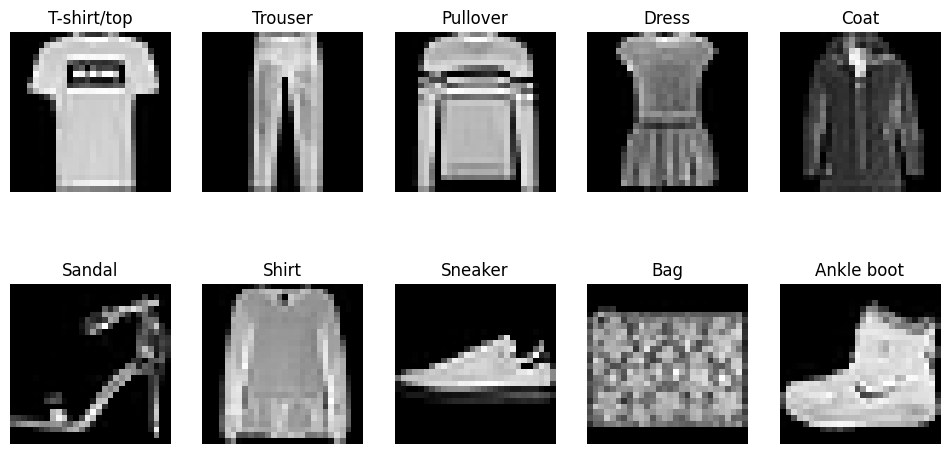

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    index = np.where(y_train == i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')

plt.show()

In [ ]:
def build_model(optimizer, lr):
    model = keras.Sequential([
        keras.layers.Input(shape=(784,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=optimizer(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
def plot_metrics(y_true, y_pred, y_proba, history, class_names, title="Model"):

    plt.figure(figsize=(12,10))

    # ----------------------------
    # 1. Confusion Matrix (FIXED)
    # ----------------------------
    plt.subplot(2,2,1)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm,
                annot=True,              # ✅ numbers inside boxes
                fmt='d',                 # integer format
                cmap='Blues',
                xticklabels=class_names, # ✅ class labels
                yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    # ----------------------------
    # 2. ROC Curve
    # ----------------------------
    plt.subplot(2,2,2)

    y_bin = label_binarize(y_true, classes=range(len(class_names)))

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(fontsize=7)

    # ----------------------------
    # 3. Accuracy Curve
    # ----------------------------
    plt.subplot(2,2,3)
    if history is not None:
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy vs Epoch")
        plt.legend()
    else:
        plt.text(0.3, 0.5, "No history available")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
optimizers = {
    "SGD": keras.optimizers.SGD,
    "Adam": keras.optimizers.Adam,
    "RMSprop": keras.optimizers.RMSprop
}

learning_rates = [0.001, 0.01]
epochs_list = [10, 15, 20]
batch_sizes = [32]


Training: SGD, LR=0.001, Epoch=10, BS=32


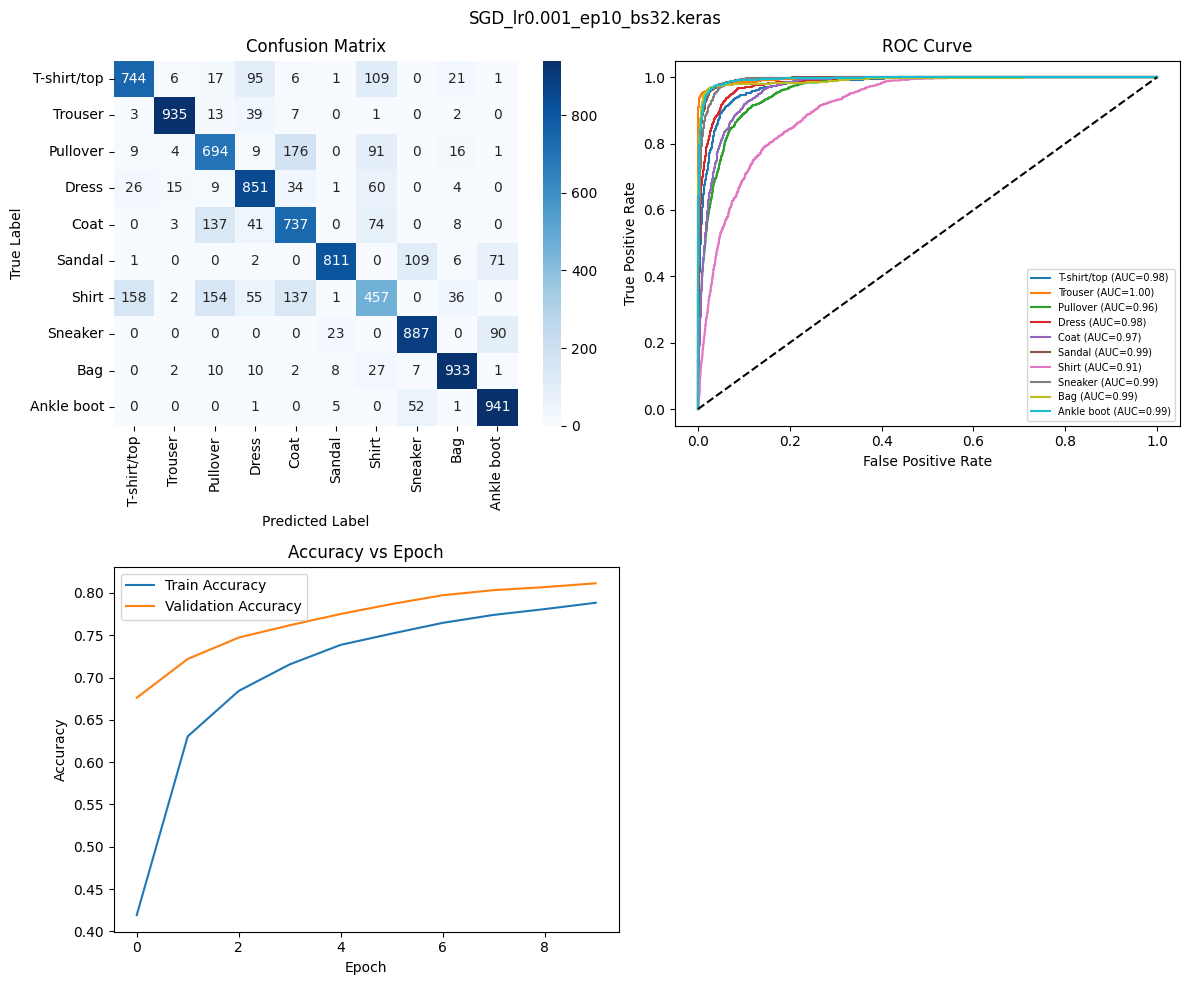


Training: SGD, LR=0.001, Epoch=15, BS=32


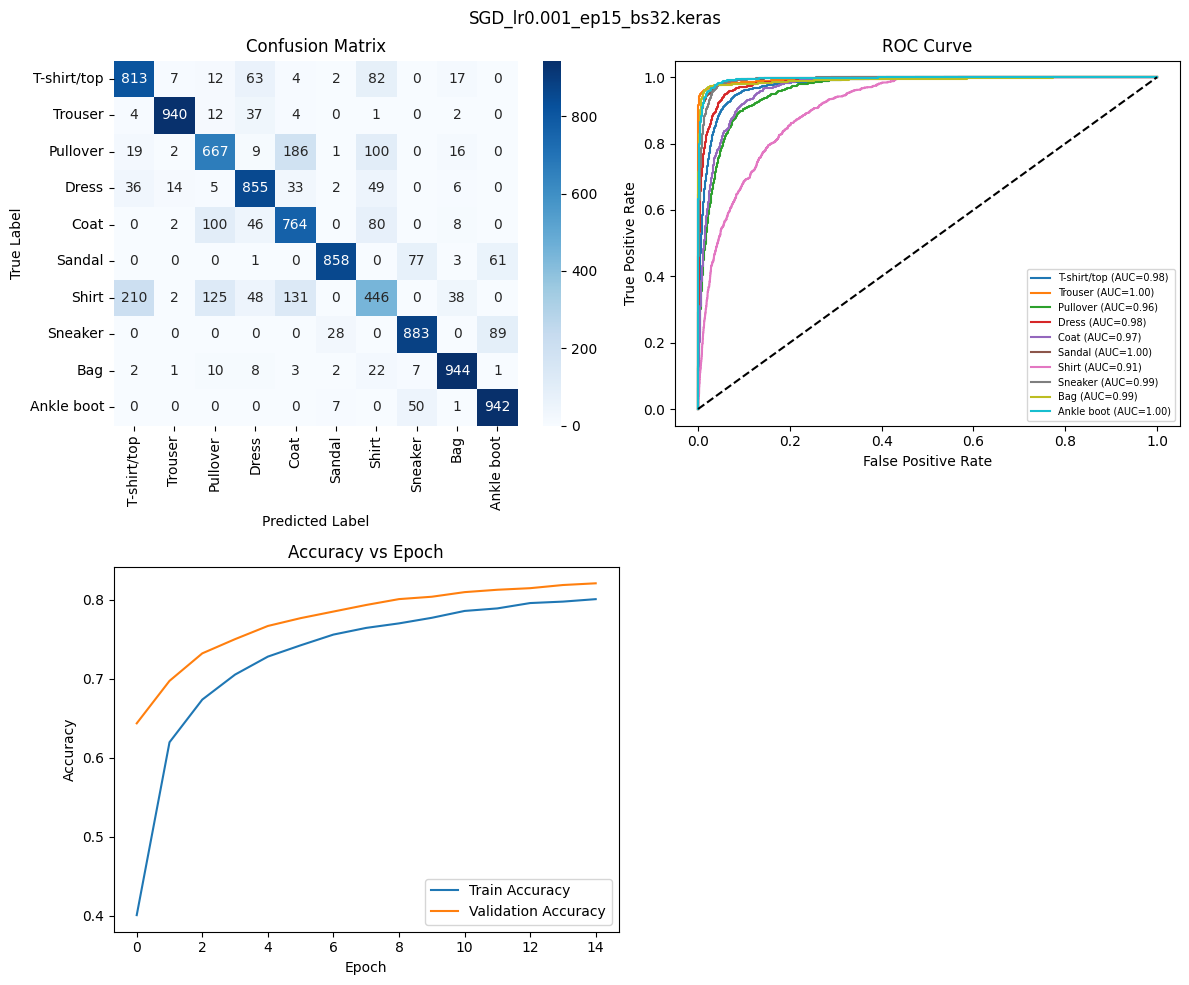


Training: SGD, LR=0.001, Epoch=20, BS=32


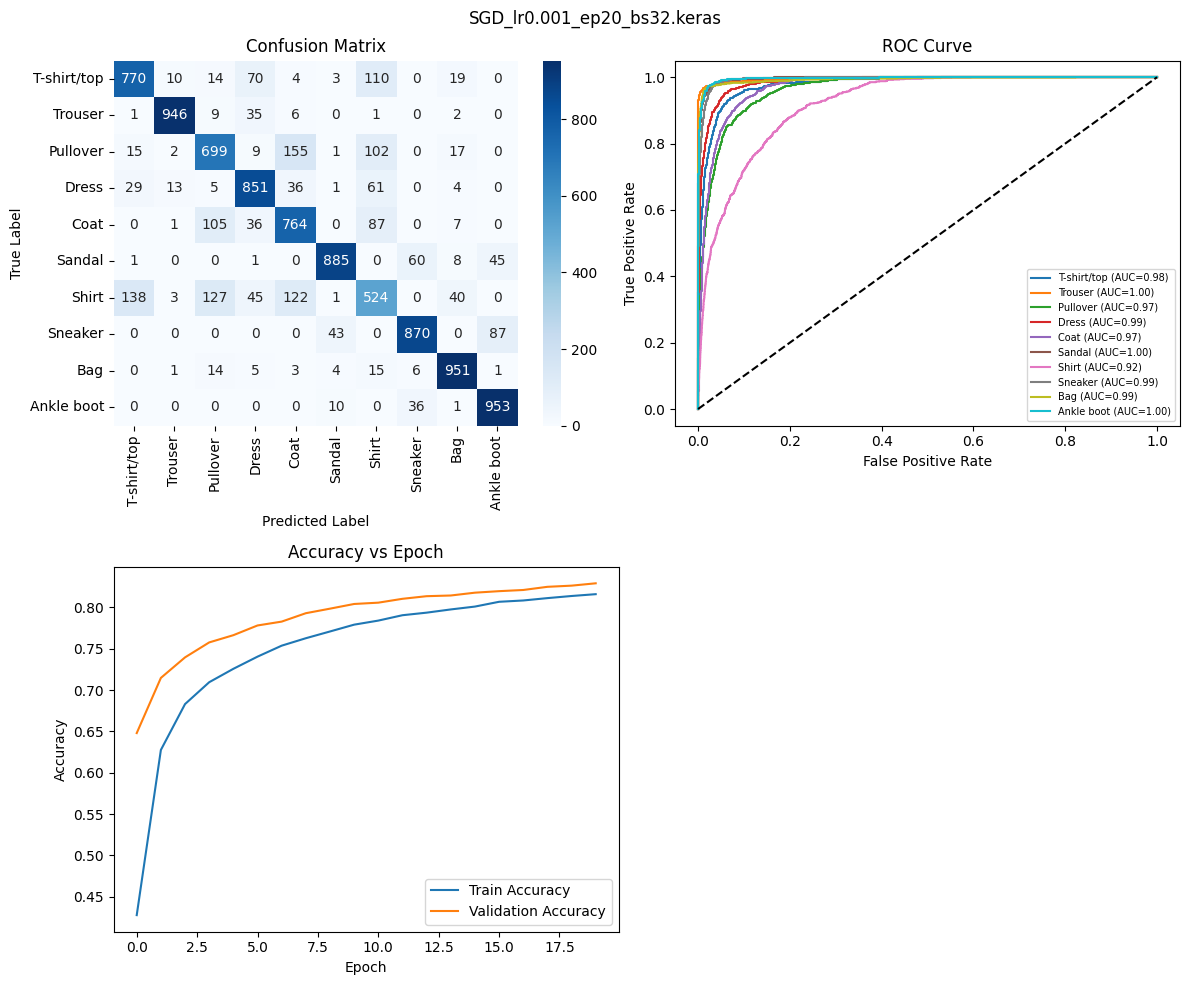


Training: SGD, LR=0.01, Epoch=10, BS=32


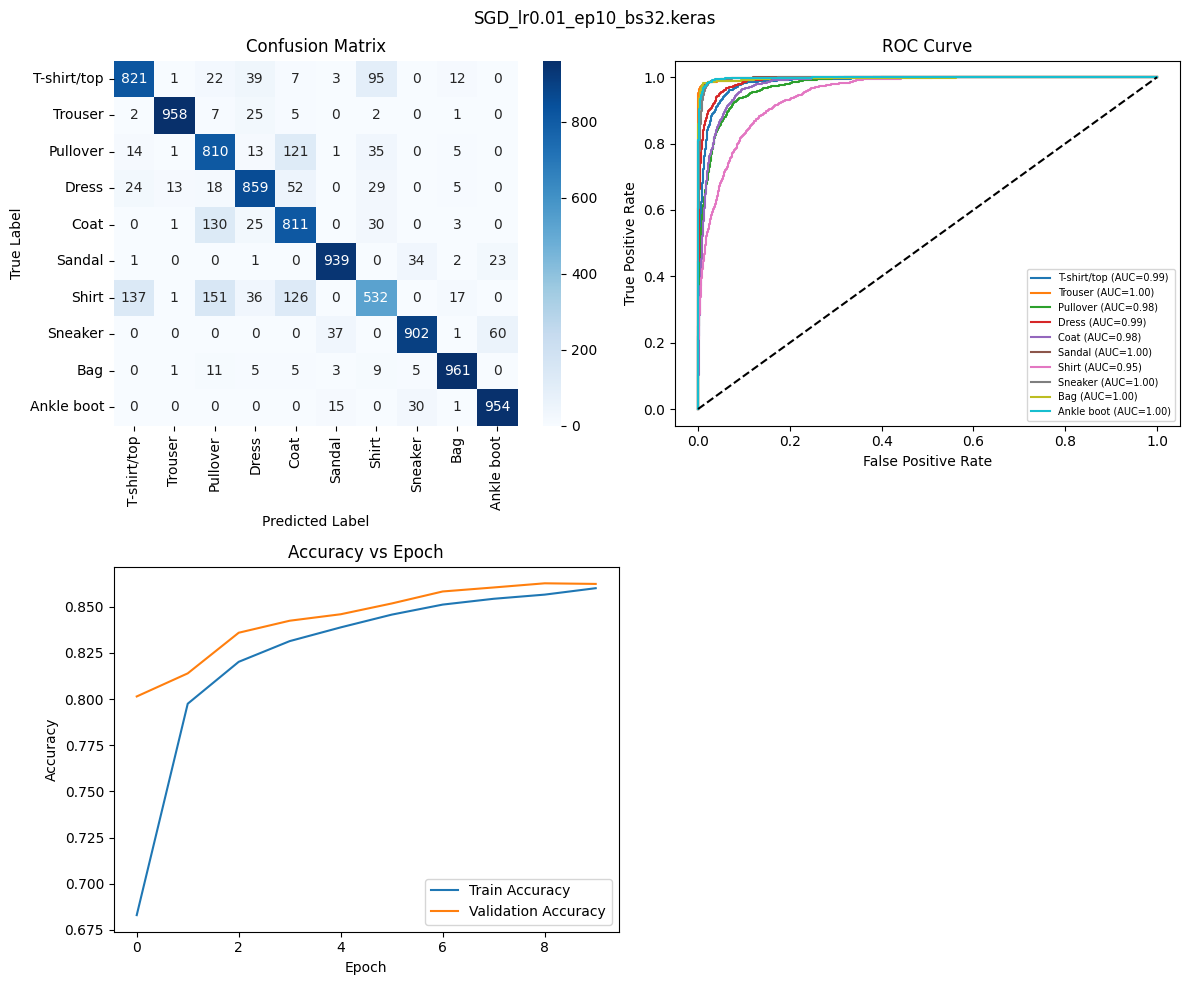


Training: SGD, LR=0.01, Epoch=15, BS=32


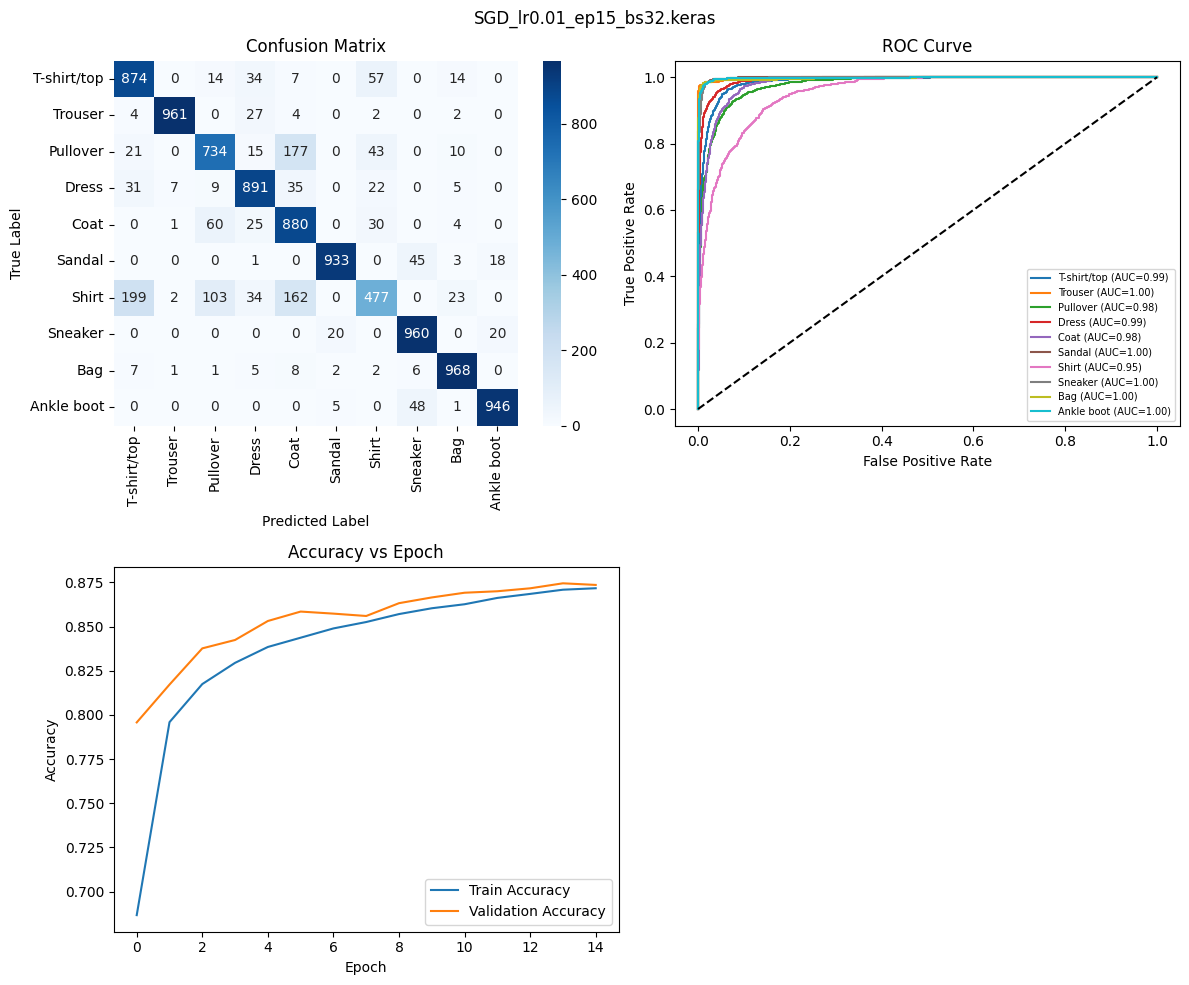


Training: SGD, LR=0.01, Epoch=20, BS=32


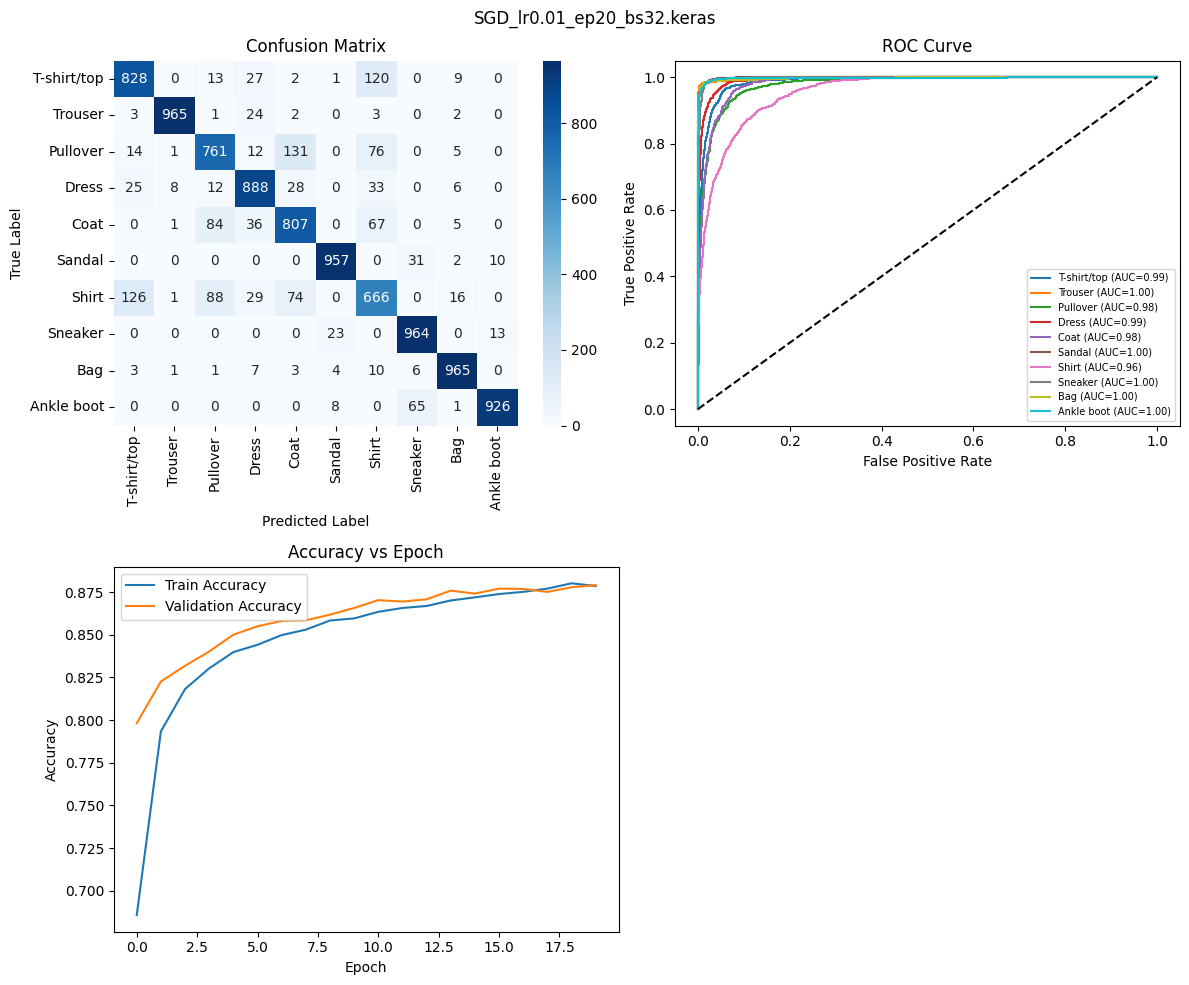


Training: Adam, LR=0.001, Epoch=10, BS=32


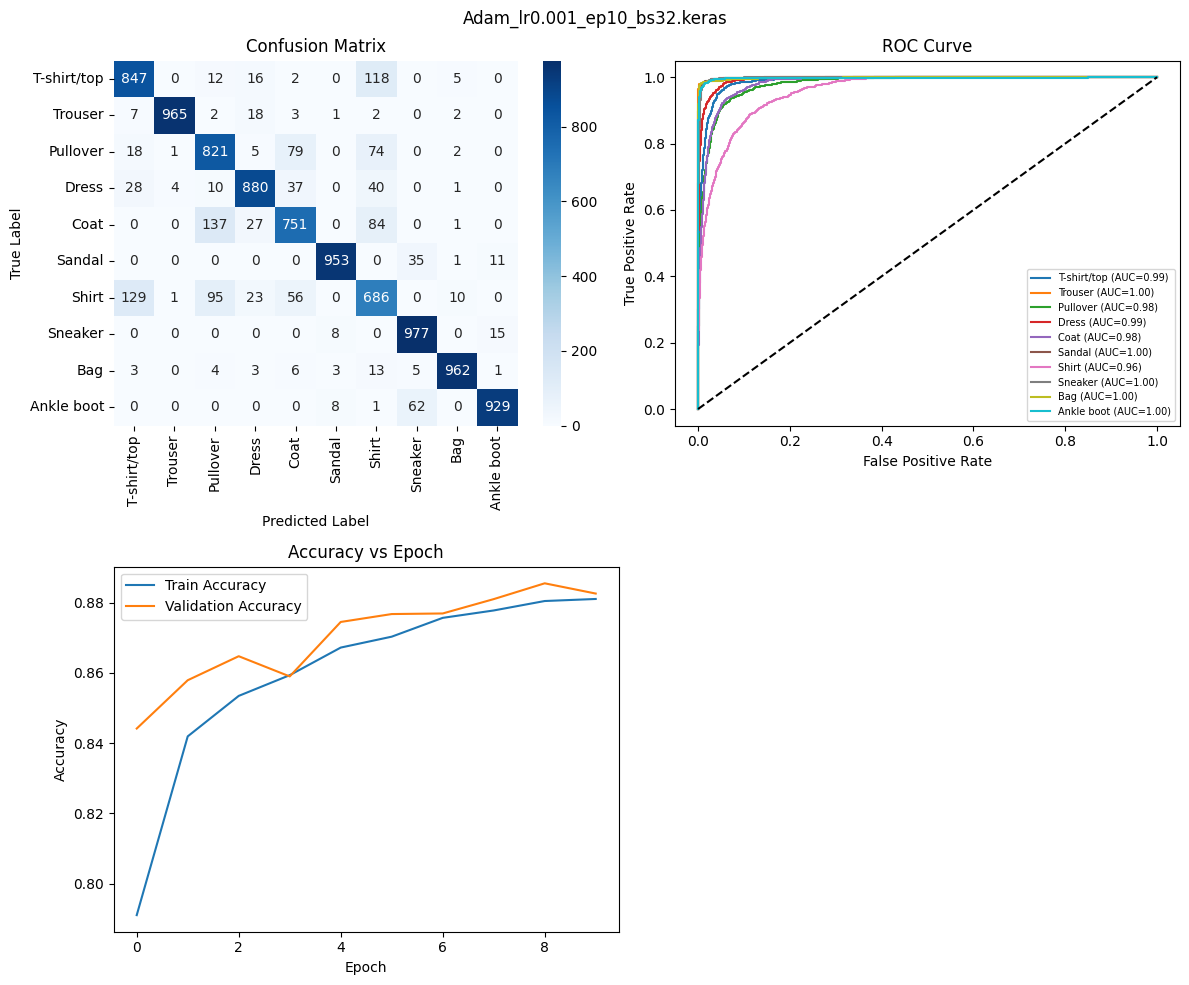


Training: Adam, LR=0.001, Epoch=15, BS=32


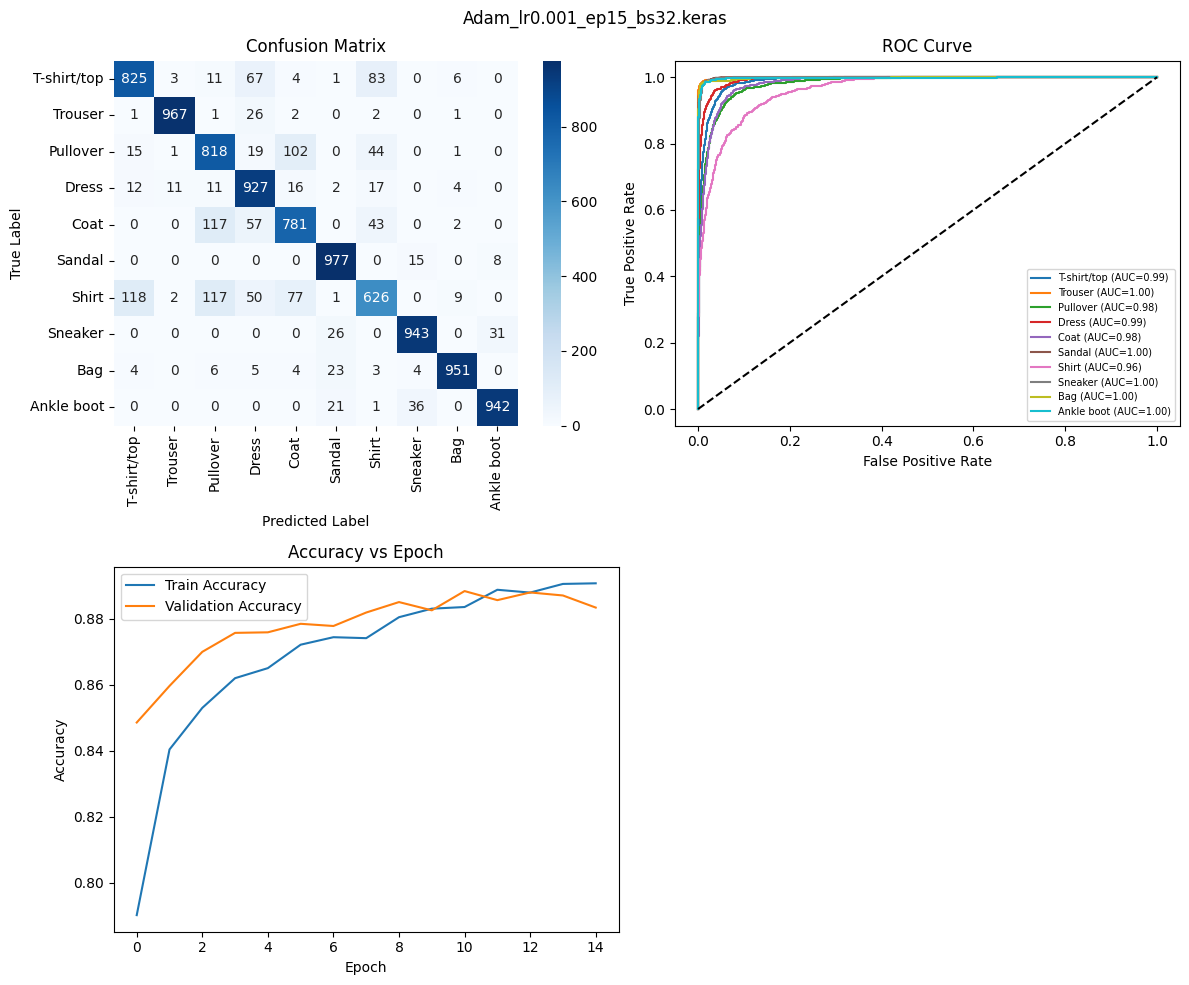


Training: Adam, LR=0.001, Epoch=20, BS=32


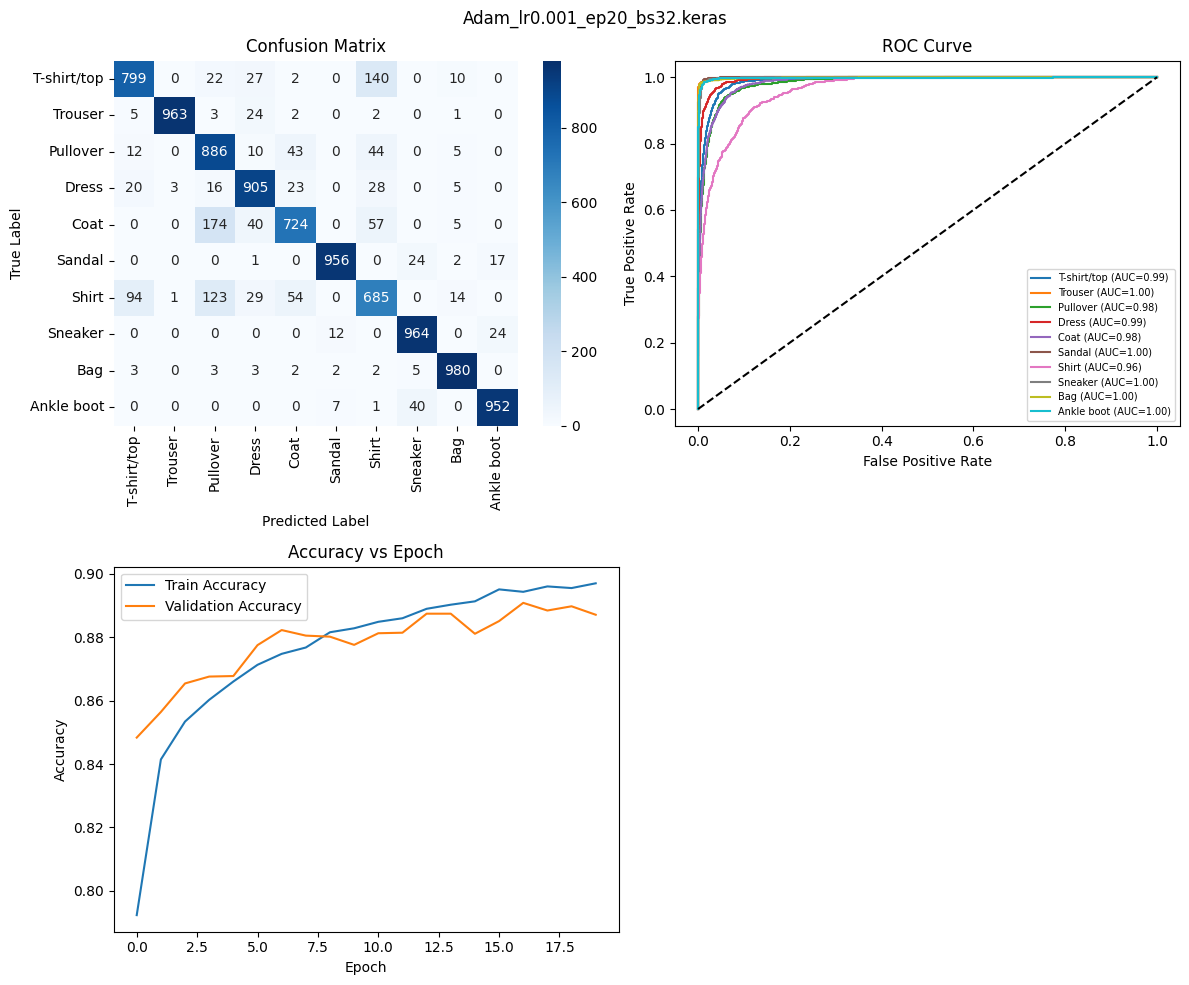


Training: Adam, LR=0.01, Epoch=10, BS=32


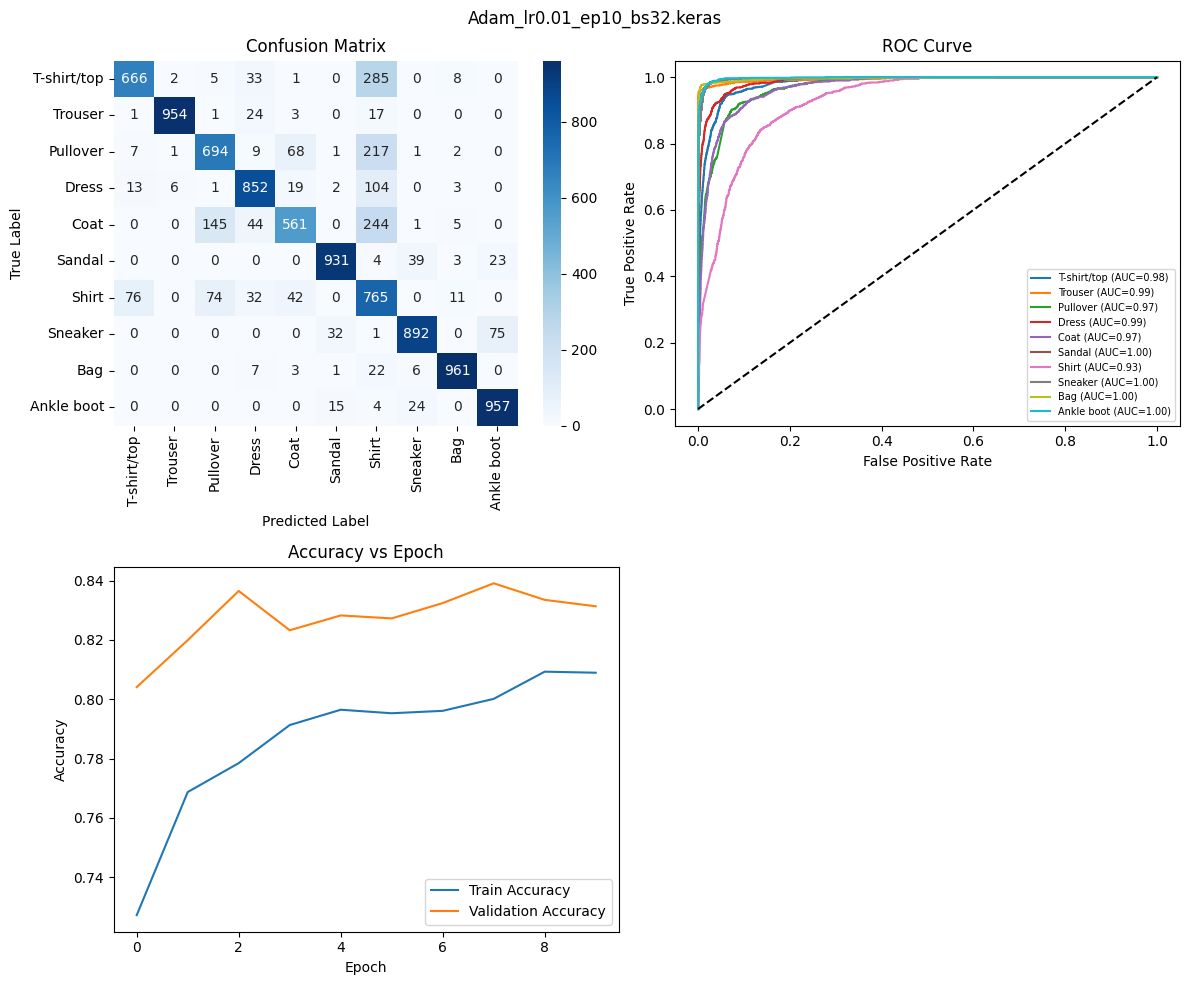


Training: Adam, LR=0.01, Epoch=15, BS=32


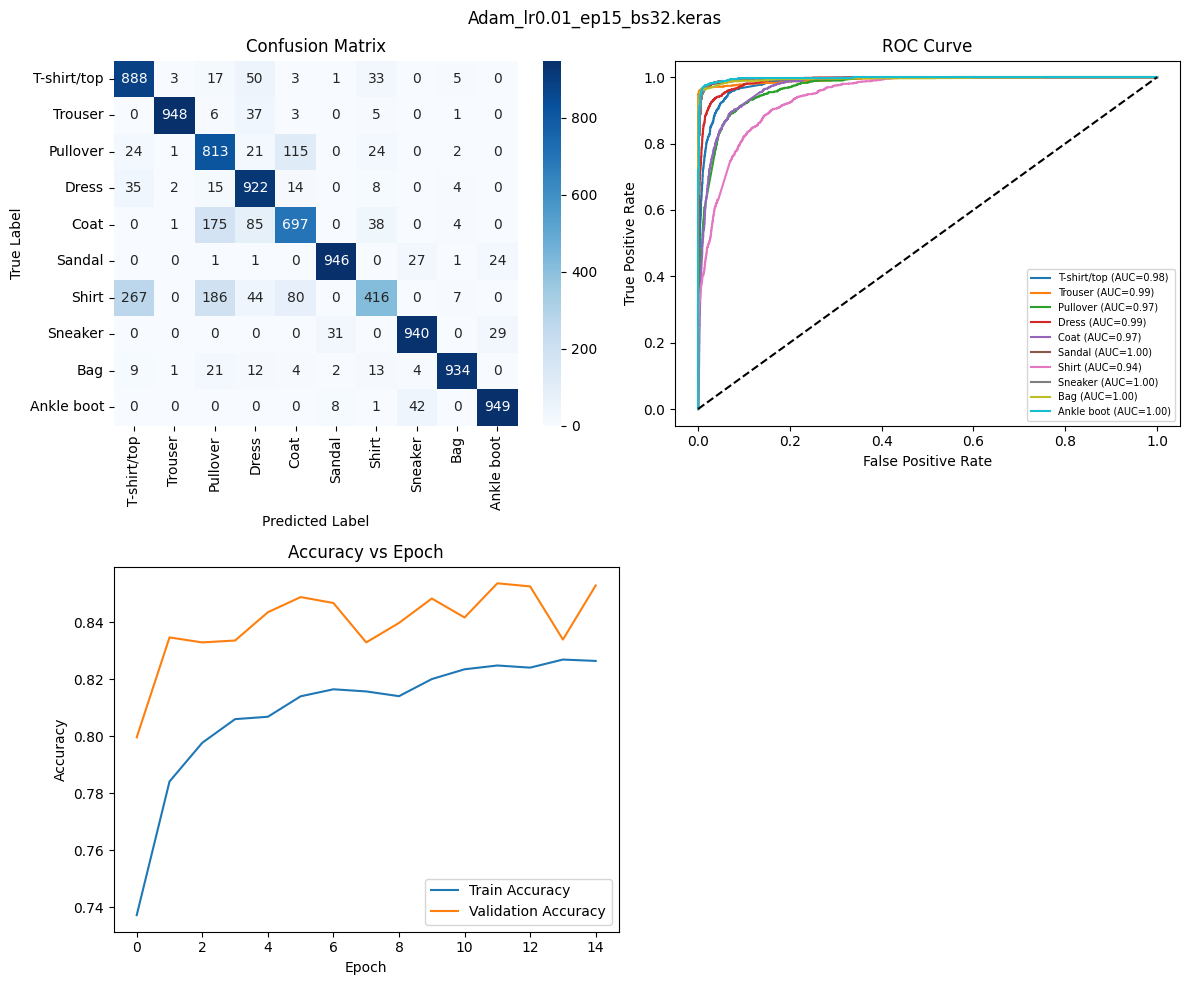


Training: Adam, LR=0.01, Epoch=20, BS=32


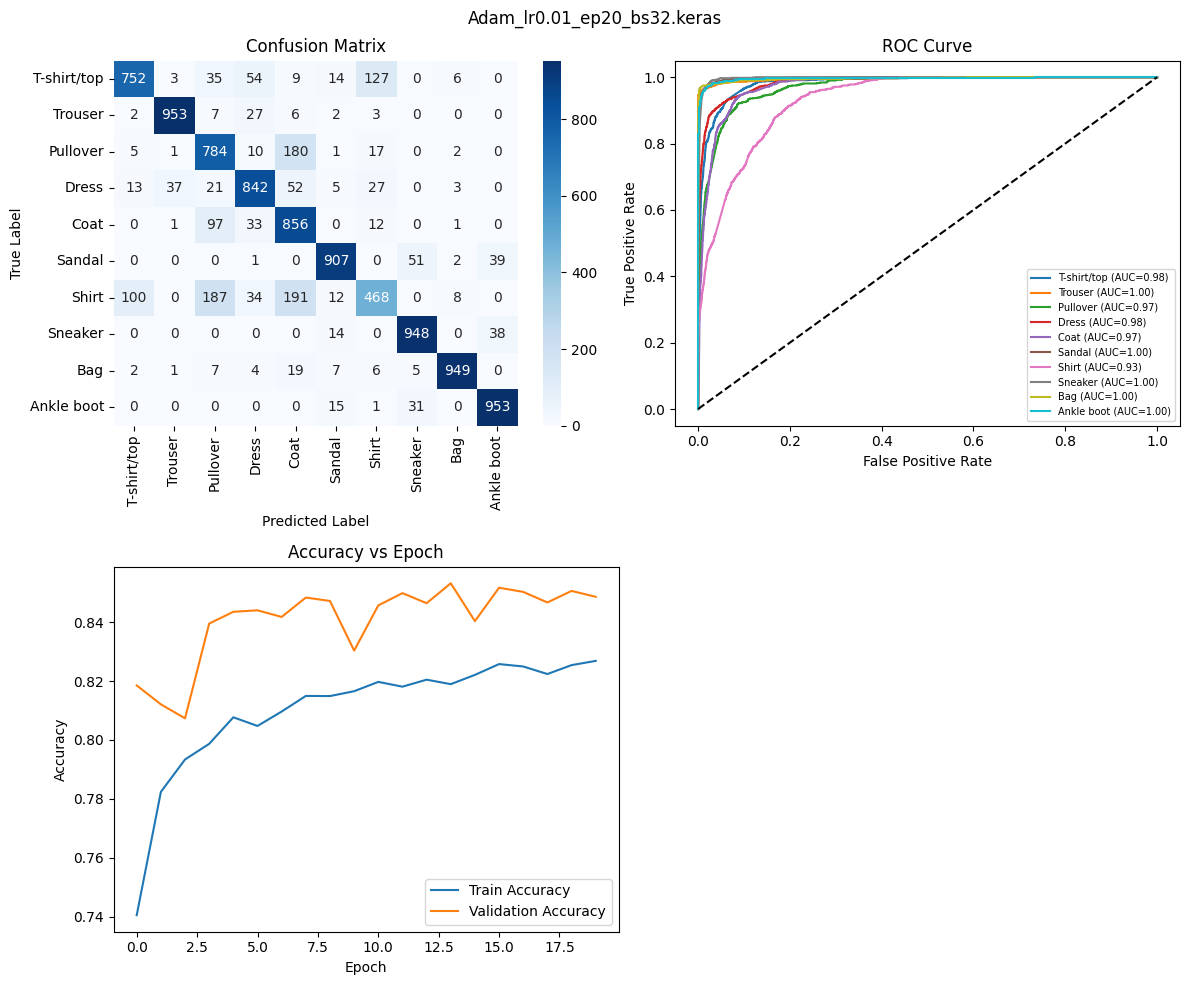


Training: RMSprop, LR=0.001, Epoch=10, BS=32


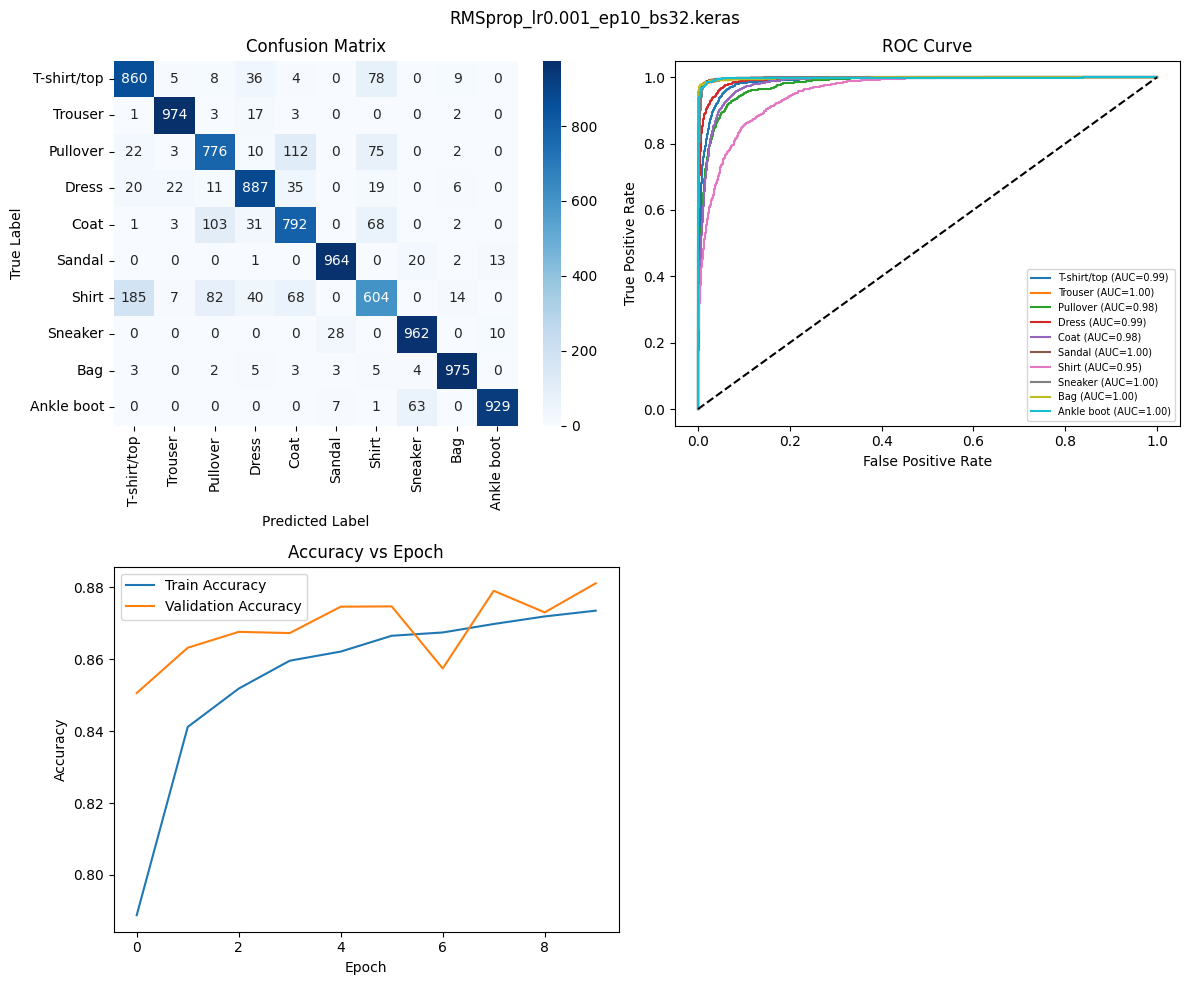


Training: RMSprop, LR=0.001, Epoch=15, BS=32


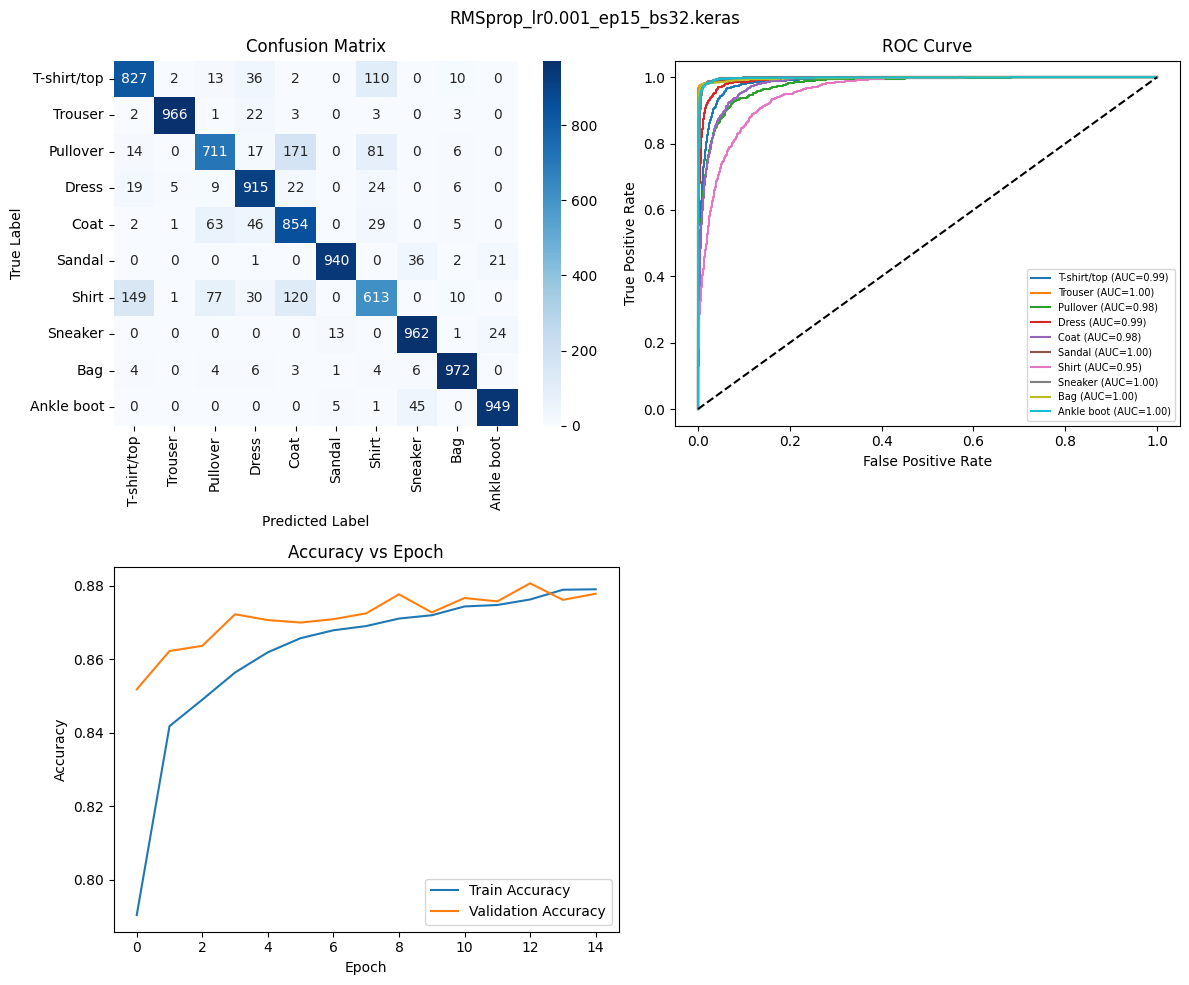


Training: RMSprop, LR=0.001, Epoch=20, BS=32


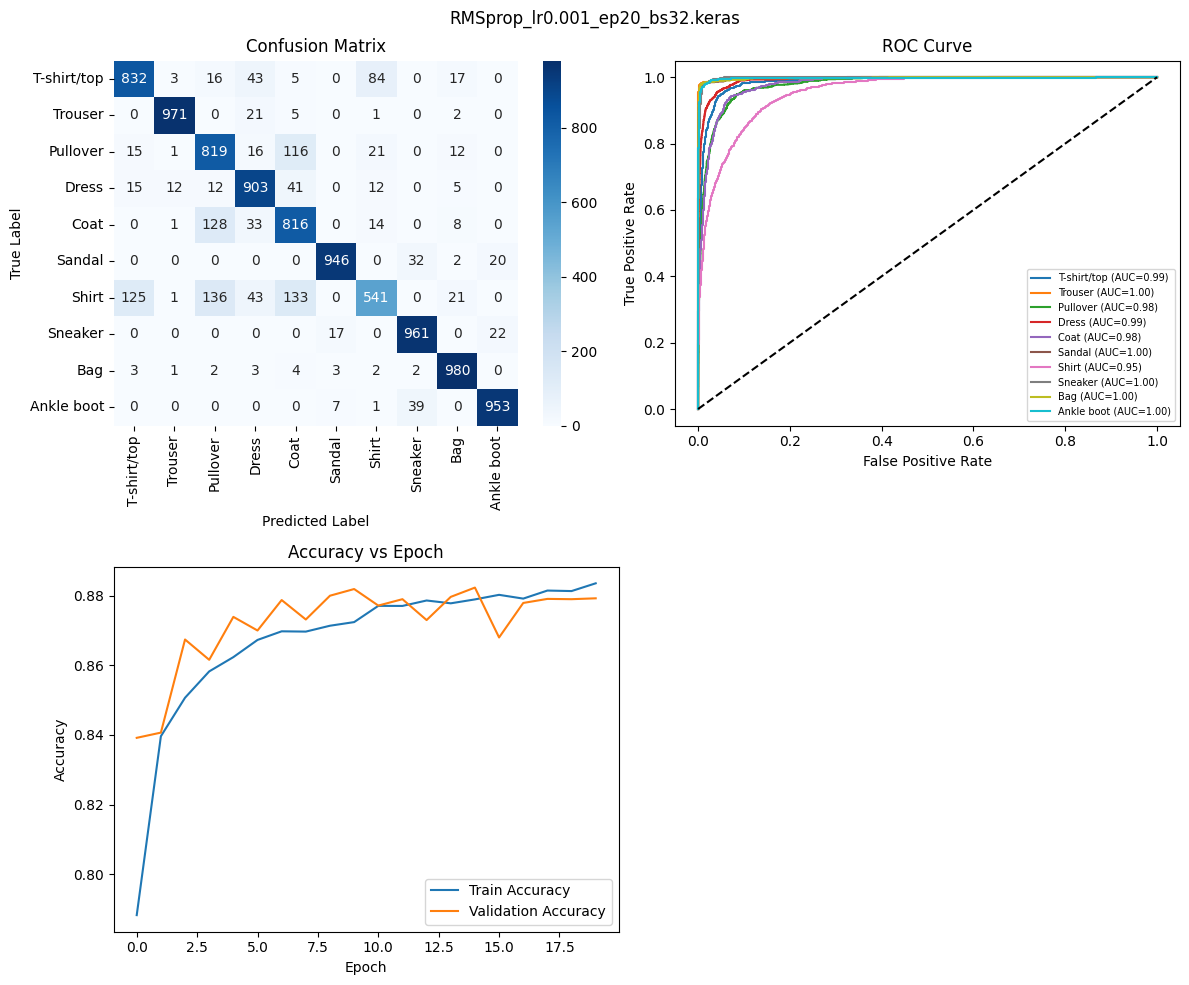


Training: RMSprop, LR=0.01, Epoch=10, BS=32


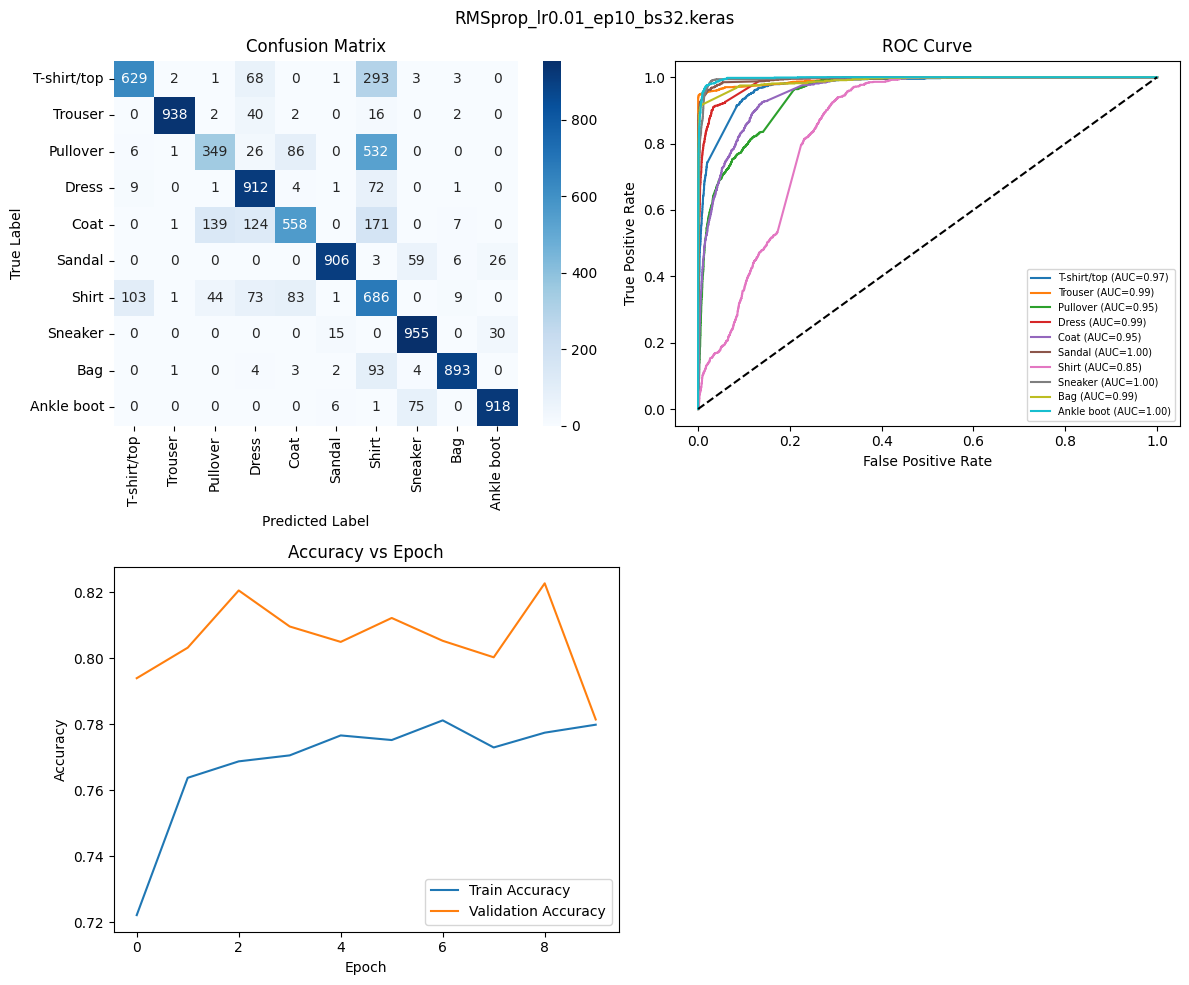


Training: RMSprop, LR=0.01, Epoch=15, BS=32


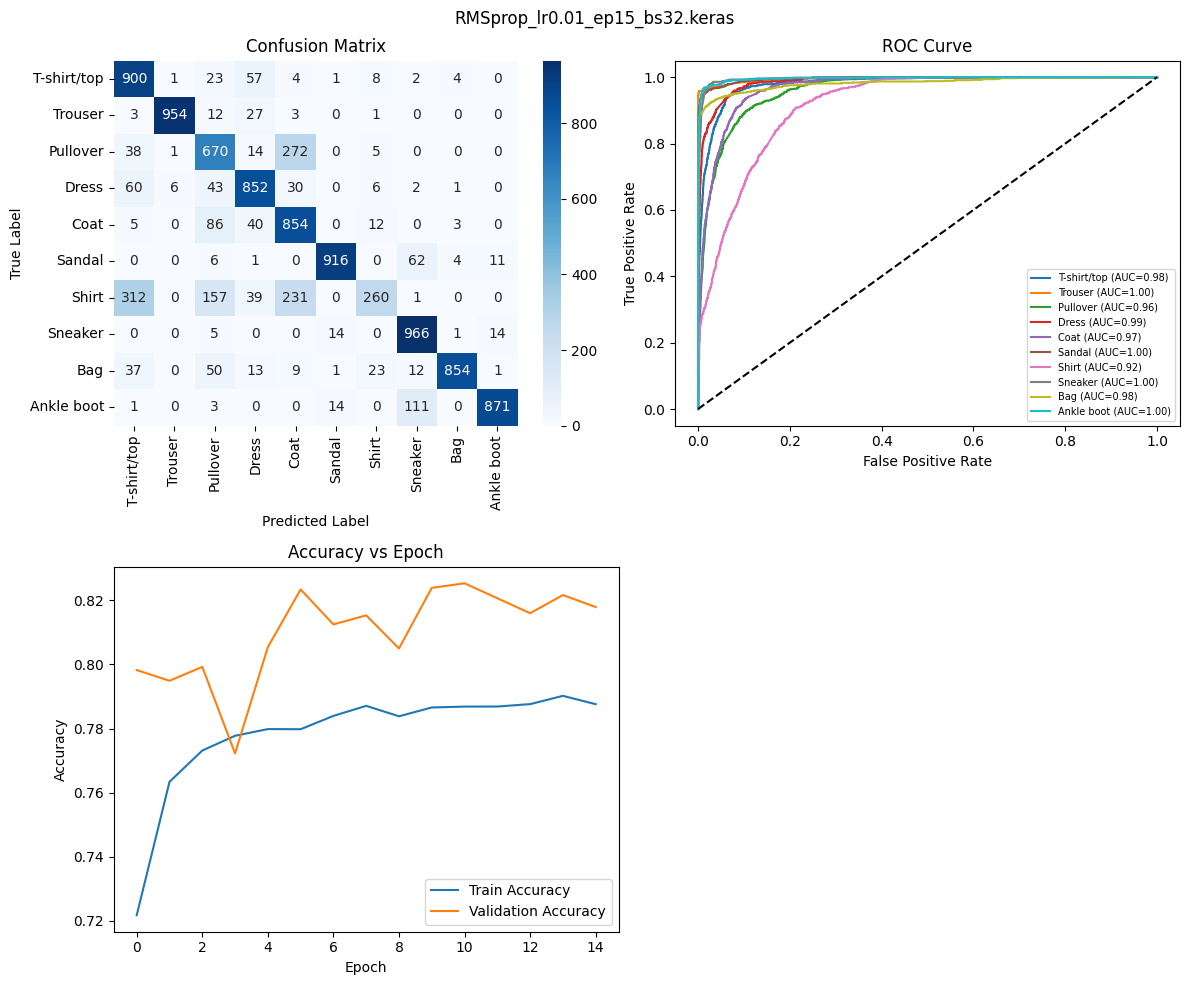


Training: RMSprop, LR=0.01, Epoch=20, BS=32


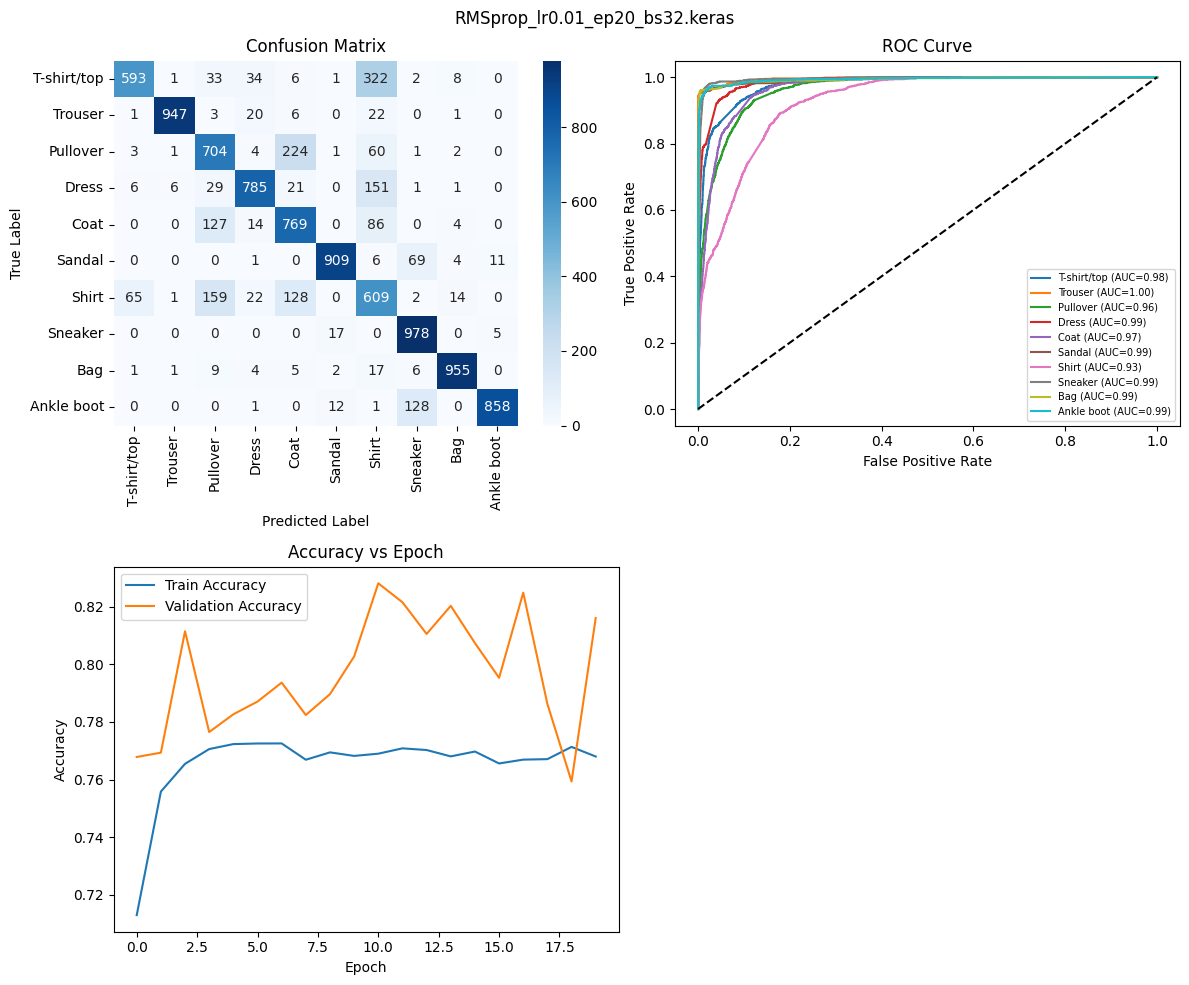

In [ ]:
results = []
best_acc = 0
best_model_name = ""

for opt_name, opt_class in optimizers.items():
    for lr in learning_rates:
        for ep in epochs_list:
            for bs in batch_sizes:

                print(f"\nTraining: {opt_name}, LR={lr}, Epoch={ep}, BS={bs}")

                model = build_model(opt_class, lr)

                history = model.fit(
                    x_train_flat, y_train,
                    validation_split=0.2,
                    epochs=ep,
                    batch_size=bs,
                    verbose=0
                )

                # Predictions
                y_proba = model.predict(x_test_flat, verbose=0)
                y_pred = np.argmax(y_proba, axis=1)

                # Metrics
                test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
                f1 = f1_score(y_test, y_pred, average='macro')
                recall = recall_score(y_test, y_pred, average='macro')
                precision = precision_score(y_test, y_pred, average='macro')

                # Save model
                model_name = f"{opt_name}_lr{lr}_ep{ep}_bs{bs}.keras"
                model.save(model_name)

                # Save best model
                if test_acc > best_acc:
                    best_acc = test_acc
                    best_model_name = model_name

                # Save results
                results.append({
                    "Optimizer": opt_name,
                    "LR": lr,
                    "Epoch": ep,
                    "Batch Size": bs,
                    "Test Accuracy": test_acc,
                    "F1": f1,
                    "Recall": recall,
                    "Precision": precision
                })

                # Visualization (IMPORTANT)
                plot_metrics(
                  y_test,
                  y_pred,
                  y_proba,
                  history,
                  class_names,   # ✅ ADD THIS
                  title=model_name
              )

In [ ]:

df.to_excel("results.xlsx", index=False)
print(df)

   Optimizer     LR  Epoch  Batch Size  Test Accuracy        F1  Recall  \
0        SGD  0.001     10          32         0.7990  0.796838  0.7990   
1        SGD  0.001     15          32         0.8112  0.808044  0.8112   
2        SGD  0.001     20          32         0.8213  0.819924  0.8213   
3        SGD  0.010     10          32         0.8547  0.852855  0.8547   
4        SGD  0.010     15          32         0.8624  0.858451  0.8624   
5        SGD  0.010     20          32         0.8727  0.872549  0.8727   
6       Adam  0.001     10          32         0.8771  0.877648  0.8771   
7       Adam  0.001     15          32         0.8757  0.874433  0.8757   
8       Adam  0.001     20          32         0.8814  0.881142  0.8814   
9       Adam  0.010     10          32         0.8233  0.828174  0.8233   
10      Adam  0.010     15          32         0.8453  0.840132  0.8453   
11      Adam  0.010     20          32         0.8412  0.838557  0.8412   
12   RMSprop  0.001     1

In [ ]:
best_model = keras.models.load_model(best_model_name)
print("Best Model:", best_model_name)

Best Model: Adam_lr0.001_ep20_bs32.keras


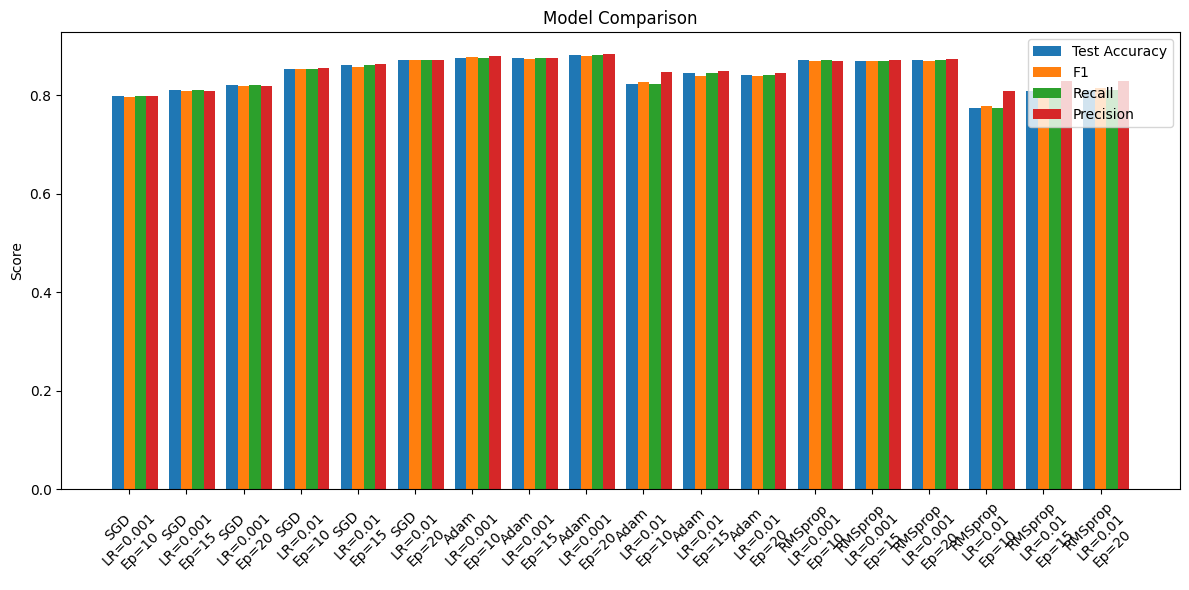

In [ ]:
metrics = ["Test Accuracy", "F1", "Recall", "Precision"]

x = range(len(df))
bar_width = 0.2

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(
        [p + i*bar_width for p in x],
        df[metric],
        bar_width,
        label=metric
    )

labels = [
    f"{row['Optimizer']}\nLR={row['LR']}\nEp={row['Epoch']}"
    for _, row in df.iterrows()
]

plt.xticks([p + bar_width for p in x], labels, rotation=45)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import requests
from io import BytesIO

url = "https://png.pngtree.com/png-clipart/20230927/original/pngtree-bag-school-png-png-image_13141451.png"

img = Image.open(BytesIO(requests.get(url).content)).convert('L')
img = img.resize((28,28))
img = np.array(img) / 255.0
img = img.reshape(1, -1)

pred = np.argmax(best_model.predict(img), axis=1)

print("Predicted class:", class_names[pred[0]])

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step
Predicted class: Bag


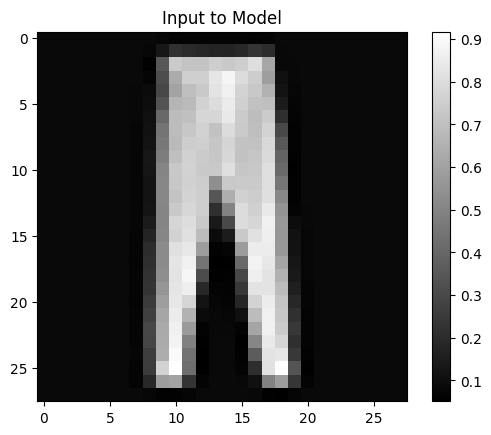

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted class: Trouser


In [ ]:
from PIL import Image
import requests
from io import BytesIO

url = "https://img.freepik.com/premium-psd/sports-track-pant-png-isolated-transparent-background_645927-32569.jpg"

img = Image.open(BytesIO(requests.get(url).content)).convert('L')
img = img.resize((28,28))
img = np.array(img) / 255.0
img = 1 - img #inverted the image as dataset has black background
img = img.reshape(1, -1)
plt.imshow(img.reshape(28,28), cmap='gray')
plt.title("Input to Model")
plt.colorbar()
plt.show()

pred = np.argmax(best_model.predict(img), axis=1)

print("Predicted class:", class_names[pred[0]])